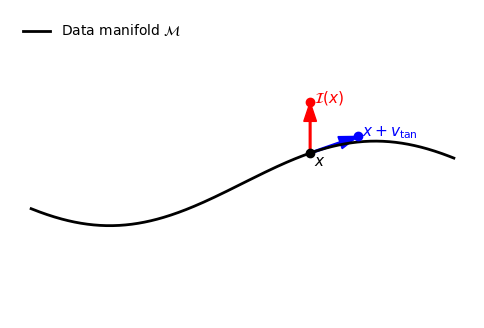

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# Create a toy "manifold"
t = np.linspace(-2.5, 2.5, 400)
x_manifold = t
y_manifold = 0.5 * np.sin(t)

# Choose a point on the manifold
t0 = 0.8
x0 = t0
y0 = 0.5 * np.sin(t0)

# Tangent direction (approx)
dx = 1.0
dy = 0.5 * np.cos(t0)

# Normalize tangent
norm = np.sqrt(dx**2 + dy**2)
dx /= norm
dy /= norm

# Small steps
eps = 0.6

# Input-space (coordinate) perturbation
x_off = x0
y_off = y0 + eps

# Tangent perturbation
x_tan = x0 + eps * dx
y_tan = y0 + eps * dy

# Plot
plt.figure(figsize=(6, 4))
plt.plot(x_manifold, y_manifold, color="black", linewidth=2, label=r"Data manifold $\mathcal{M}$")

# Original point
plt.scatter([x0], [y0], color="black", zorder=5)
plt.text(x0 + 0.05, y0 - 0.15, r"$x$", fontsize=11)

# Coordinate perturbation (off-manifold)
plt.arrow(
    x0, y0,
    x_off - x0, y_off - y0,
    width=0.02, head_width=0.15,
    length_includes_head=True,
    color="red"
)
plt.scatter([x_off], [y_off], color="red", zorder=5)
plt.text(x_off + 0.05, y_off, r"$\mathcal{I}(x)$", color="red", fontsize=11)

# Tangent perturbation (near-manifold)
plt.arrow(
    x0, y0,
    x_tan - x0, y_tan - y0,
    width=0.02, head_width=0.15,
    length_includes_head=True,
    color="blue"
)
plt.scatter([x_tan], [y_tan], color="blue", zorder=5)
plt.text(x_tan + 0.05, y_tan, r"$x + v_{\mathrm{tan}}$", color="blue", fontsize=11)

# Styling
plt.axis("equal")
plt.axis("off")
plt.legend(frameon=False, loc="upper left")

#plt.tight_layout()
# plt.show()
plt.savefig("input_vs_tangent_perturbations.pdf", dpi=300)

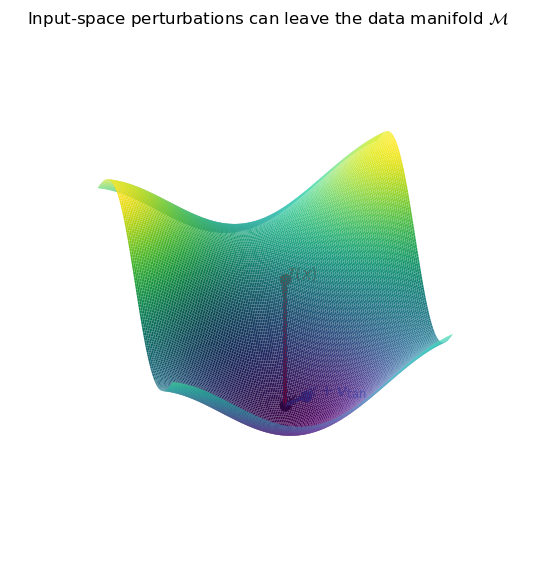

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from mpl_toolkits.mplot3d import proj3d

# ----------------------------
# Surface (data manifold)
# ----------------------------
def f(x, y):
    return -1*(0.35*np.sin(1.2*x) + 0.25*np.cos(1.1*y))

xs = np.linspace(-2.5, 2.5, 160)
ys = np.linspace(-2.5, 2.5, 160)
X, Y = np.meshgrid(xs, ys)
Z = f(X, Y)

# Lighting for "solid / shiny" look
ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(Z, cmap=plt.cm.viridis, vert_exag=0.7, blend_mode="soft")

# ----------------------------
# Plot setup (set view FIRST)
# ----------------------------
fig = plt.figure(figsize=(7.5, 5.8))
ax = fig.add_subplot(111, projection="3d")

elev, azim = 40, -15
ax.view_init(elev=elev, azim=azim)

# Use orthographic projection to reduce weird depth artifacts (optional but helpful)
ax.set_proj_type("ortho")

# ----------------------------
# Choose a point that is actually "front-most" in this view
# by maximizing projected depth.
# ----------------------------
P = np.stack([X, Y, Z], axis=-1).reshape(-1, 3)

R = np.sqrt(P[:, 0]**2 + P[:, 1]**2)
mask = R <= 2.0

M = ax.get_proj()
x2, y2, z2 = proj3d.proj_transform(P[:, 0], P[:, 1], P[:, 2], M)

z2 = np.array(z2)
z2[~mask] = -np.inf
idx = np.argmax(z2)

x0, y0, z0 = P[idx]

# --- requested change: shift x0 by +2 and keep the point on the surface
x0 = x0
z0 = f(x0, y0)

# ----------------------------
# Define a camera-direction lift so arrows sit in front of the surface
# ----------------------------
ae = np.deg2rad(elev)
aa = np.deg2rad(azim)
cam_dir = np.array([np.cos(ae)*np.cos(aa), np.cos(ae)*np.sin(aa), np.sin(ae)], float)
cam_dir /= np.linalg.norm(cam_dir)

# lift = 0.25
# p0 = np.array([x0, y0, z0]) + lift * cam_dir

# ----------------------------
# Perturbations
# ----------------------------
eps_red = 0.9
eps_blue = 0.55

p_red_end = p0 + np.array([0.0, 0.0, eps_red])

h = 1e-4
fx = (f(x0 + h, y0) - f(x0 - h, y0)) / (2*h)
fy = (f(x0, y0 + h) - f(x0, y0 - h)) / (2*h)

ux, uy = 1.0, 0.6
uz = fx*ux + fy*uy
t = np.array([ux, uy, uz], float)
t /= np.linalg.norm(t)

p_blue_end = p0 + eps_blue * t

# ----------------------------
# Draw surface (solid)
# ----------------------------
ax.plot_surface(
    X, Y, Z,
    facecolors=rgb,
    rstride=1, cstride=1,
    linewidth=0,
    antialiased=True,
    shade=False,
    alpha=1.0,
    zsort="min"
)

# ----------------------------
# Draw point + arrows (lifted toward camera)
# ----------------------------
ax.scatter([p0[0]], [p0[1]], [p0[2]], s=55, color="black", depthshade=False)
ax.text(p0[0], p0[1], p0[2], "$x$", fontsize=12, color="black")

ax.quiver(
    p0[0], p0[1], p0[2],
    p_red_end[0]-p0[0], p_red_end[1]-p0[1], p_red_end[2]-p0[2],
    color="red", linewidth=2.8, arrow_length_ratio=0.12
)
ax.scatter([p_red_end[0]], [p_red_end[1]], [p_red_end[2]], s=55, color="red", depthshade=False)
ax.text(p_red_end[0], p_red_end[1], p_red_end[2], "$\\mathcal{I}(x)$", fontsize=12, color="red")

ax.quiver(
    p0[0], p0[1], p0[2],
    p_blue_end[0]-p0[0], p_blue_end[1]-p0[1], p_blue_end[2]-p0[2],
    color="dodgerblue", linewidth=2.8, arrow_length_ratio=0.12
)
ax.scatter([p_blue_end[0]], [p_blue_end[1]], [p_blue_end[2]], s=55, color="dodgerblue", depthshade=False)
ax.text(p_blue_end[0], p_blue_end[1], p_blue_end[2], "$x+v_{\\mathrm{tan}}$", fontsize=12, color="dodgerblue")

ax.set_axis_off()
ax.set_title(r"Input-space perturbations can leave the data manifold $\mathcal{M}$", pad=14)
plt.tight_layout()
plt.show()


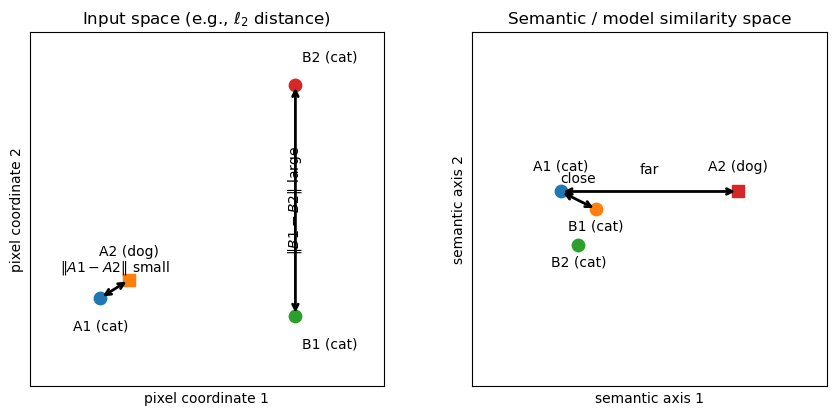

In [75]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Diagram 3: Input-space distance vs semantic difference
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))

# -------------------------
# Left: Input space (L2)
# -------------------------
ax = axes[0]
ax.set_title("Input space (e.g., $\\ell_2$ distance)")

# Pair A: close in input, different semantics
A1 = (0.2, 0.25)   # "cat"
A2 = (0.28, 0.30)  # "dog" (very close to A1)

# Pair B: far in input, same semantics
B1 = (0.75, 0.20)  # "cat"
B2 = (0.75, 0.85)  # "cat" (far from B1)

# Plot points (use marker shape to encode semantics)
# Semantics: "cat" = circle, "dog" = square
ax.scatter(*A1, s=80, marker="o")
ax.scatter(*A2, s=80, marker="s")
ax.scatter(*B1, s=80, marker="o")
ax.scatter(*B2, s=80, marker="o")

# Labels
ax.text(A1[0], A1[1]-0.06, "A1 (cat)", ha="center", va="top", fontsize=10)
ax.text(A2[0], A2[1]+0.06, "A2 (dog)", ha="center", va="bottom", fontsize=10)
ax.text(B1[0]+0.02, B1[1]-0.06, "B1 (cat)", ha="left", va="top", fontsize=10)
ax.text(B2[0]+0.02, B2[1]+0.06, "B2 (cat)", ha="left", va="bottom", fontsize=10)

# Distance annotations
ax.annotate("", xy=A2, xytext=A1, arrowprops=dict(arrowstyle="<->", lw=2))
ax.text((A1[0]+A2[0])/2, (A1[1]+A2[1])/2 + 0.05, r"$\|A1-A2\|\ \text{small}$",
        ha="center", fontsize=10)

ax.annotate("", xy=B2, xytext=B1, arrowprops=dict(arrowstyle="<->", lw=2))
ax.text(B1[0], (B1[1]+B2[1])/2, r"$\|B1-B2\|\ \text{large}$",
        ha="center", va="center", fontsize=10, rotation=90)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("pixel coordinate 1")
ax.set_ylabel("pixel coordinate 2")

# -------------------------
# Right: Semantic / model space
# -------------------------
ax = axes[1]
ax.set_title("Semantic / model similarity space")

# Arrange by meaning: cats near cats, dog separated
A1s = (0.25, 0.55)  # cat
B1s = (0.35, 0.50)  # cat
B2s = (0.30, 0.40)  # cat
A2s = (0.75, 0.55)  # dog

ax.scatter(*A1s, s=80, marker="o")
ax.scatter(*B1s, s=80, marker="o")
ax.scatter(*B2s, s=80, marker="o")
ax.scatter(*A2s, s=80, marker="s")

ax.text(A1s[0], A1s[1]+0.06, "A1 (cat)", ha="center", fontsize=10)
ax.text(B1s[0], B1s[1]-0.06, "B1 (cat)", ha="center", fontsize=10)
ax.text(B2s[0], B2s[1]-0.06, "B2 (cat)", ha="center", fontsize=10)
ax.text(A2s[0], A2s[1]+0.06, "A2 (dog)", ha="center", fontsize=10)

# Show that A1 is "close" to B1/B2 semantically, but far from A2
ax.annotate("", xy=B1s, xytext=A1s, arrowprops=dict(arrowstyle="<->", lw=2))
ax.text((A1s[0]+B1s[0])/2, (A1s[1]+B1s[1])/2 + 0.05, "close",
        ha="center", fontsize=10)

ax.annotate("", xy=A2s, xytext=A1s, arrowprops=dict(arrowstyle="<->", lw=2))
ax.text((A1s[0]+A2s[0])/2, (A1s[1]+A2s[1])/2 + 0.05, "far",
        ha="center", fontsize=10)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("semantic axis 1")
ax.set_ylabel("semantic axis 2")

plt.tight_layout()
plt.show()


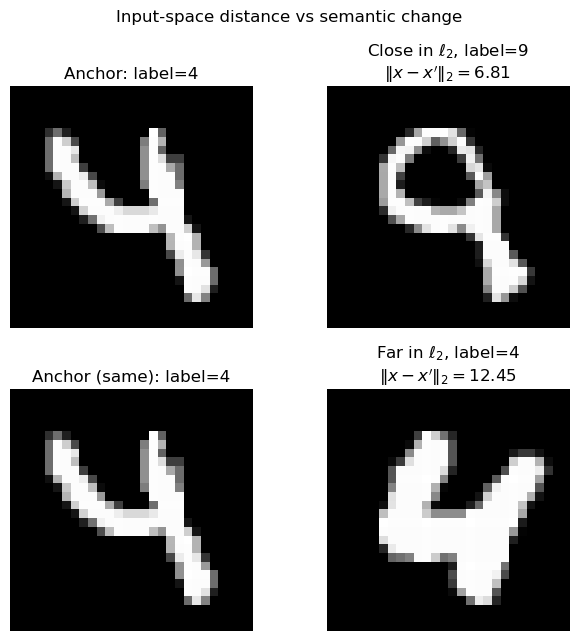

In [91]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# -----------------------------
# Load MNIST (test set)
# -----------------------------
tfm = transforms.Compose([transforms.ToTensor()])  # values in [0,1]
ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

# Flatten all images into vectors for distance computations
X = torch.stack([ds[i][0].view(-1) for i in range(len(ds))])  # [N, 784]
y = torch.tensor([ds[i][1] for i in range(len(ds))])          # [N]

# -----------------------------
# Helper: find a "close but different label" pair
# and a "far but same label" pair, using random subsampling
# -----------------------------
def find_pairs(
    X, y,
    anchor_idx=None,
    n_candidates=6000,
    seed=0,
):
    rng = random.Random(seed)
    N = X.shape[0]

    if anchor_idx is None:
        anchor_idx = rng.randrange(N)

    xa = X[anchor_idx]
    ya = int(y[anchor_idx].item())

    # Sample candidate indices (exclude anchor)
    candidates = set()
    while len(candidates) < n_candidates:
        j = rng.randrange(N)
        if j != anchor_idx:
            candidates.add(j)
    candidates = torch.tensor(sorted(candidates), dtype=torch.long)

    Xc = X[candidates]  # [M, 784]
    yc = y[candidates]  # [M]

    # L2 distances
    d = torch.norm(Xc - xa, dim=1)  # [M]

    # Pair A: small L2, different label
    mask_diff = (yc != ya)
    d_diff = d.clone()
    d_diff[~mask_diff] = float("inf")
    jA_pos = int(torch.argmin(d_diff).item())
    idxA = int(candidates[jA_pos].item())

    # Pair B: large L2, same label
    mask_same = (yc == ya)
    d_same = d.clone()
    d_same[~mask_same] = float("-inf")
    jB_pos = int(torch.argmax(d_same).item())
    idxB = int(candidates[jB_pos].item())

    # Distances
    dA = float(torch.norm(X[idxA] - xa).item())
    dB = float(torch.norm(X[idxB] - xa).item())

    return anchor_idx, idxA, dA, idxB, dB

# You can pin anchor_idx to a specific example if you want reproducibility
anchor_idx, idxA, dA, idxB, dB = find_pairs(X, y, anchor_idx=None, n_candidates=8000, seed=1)

# -----------------------------
# Plot: 2x2 "diagram 3" in MNIST
# -----------------------------
def show(img_vec):
    return img_vec.view(28, 28).cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(6.5, 6.5))
axes = axes.ravel()

xa = X[anchor_idx]
ya = int(y[anchor_idx].item())

# Pair A (close in L2, different label)
axes[0].imshow(show(xa), cmap="gray")
axes[0].set_title(f"Anchor: label={ya}")
axes[0].axis("off")

axes[1].imshow(show(X[idxA]), cmap="gray")
axes[1].set_title(f"Close in $\\ell_2$, label={int(y[idxA])}\n$\\|x-x'\\|_2={dA:.2f}$")
axes[1].axis("off")

# Pair B (far in L2, same label)
axes[2].imshow(show(xa), cmap="gray")
axes[2].set_title(f"Anchor (same): label={ya}")
axes[2].axis("off")

axes[3].imshow(show(X[idxB]), cmap="gray")
axes[3].set_title(f"Far in $\\ell_2$, label={int(y[idxB])}\n$\\|x-x'\\|_2={dB:.2f}$")
axes[3].axis("off")

plt.suptitle("Input-space distance vs semantic change", y=0.98)
plt.tight_layout()
plt.savefig("mnist_diagram3.pdf", dpi=300)

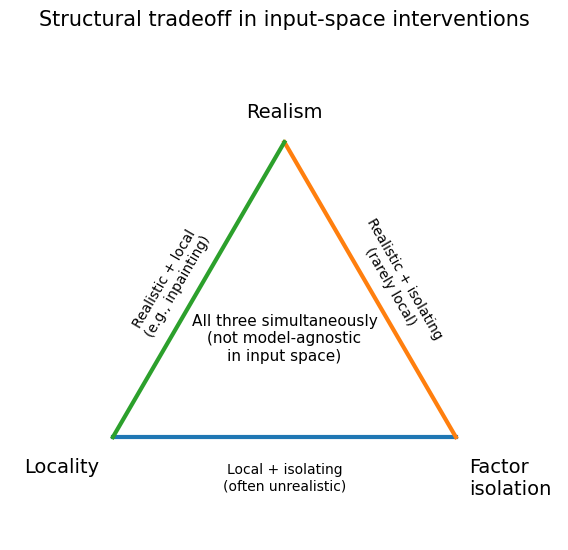

In [90]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.2, 5.6))

# Triangle vertices
A = np.array([0.0, 0.0])   # Locality
B = np.array([1.0, 0.0])   # Factor isolation
C = np.array([0.5, 0.86])  # Realism

# Triangle
ax.plot([A[0], B[0]], [A[1], B[1]], linewidth=3)
ax.plot([B[0], C[0]], [B[1], C[1]], linewidth=3)
ax.plot([C[0], A[0]], [C[1], A[1]], linewidth=3)

# Vertex labels
ax.text(A[0]-0.04, A[1]-0.06, "Locality", ha="right", va="top", fontsize=14)
ax.text(B[0]+0.04, B[1]-0.06, "Factor\nisolation", ha="left", va="top", fontsize=14)
ax.text(C[0], C[1]+0.06, "Realism", ha="center", va="bottom", fontsize=14)

# Center statement (NO X)
center = (A + B + C) / 3
ax.text(
    center[0], center[1],
    "All three simultaneously\n(not model-agnostic\nin input space)",
    ha="center",
    va="center",
    fontsize=11
)

# Edge labels (centered on edges)
def edge_label(ax, p1, p2, text, offset=(0,0), rotation=None):
    mid = (p1 + p2) / 2
    angle = np.degrees(np.arctan2(p2[1]-p1[1], p2[0]-p1[0]))
    ax.text(
        mid[0] + offset[0],
        mid[1] + offset[1],
        text,
        ha="center",
        va="center",
        fontsize=10,
        rotation=rotation if rotation is not None else angle
    )

edge_label(ax, A, B, "Local + isolating\n(often unrealistic)", offset=(0, -0.12), rotation=0)
edge_label(ax, A, C, "Realistic + local\n(e.g., inpainting)", offset=(-0.08, 0.02))
edge_label(ax, B, C, "Realistic + isolating\n(rarely local)", offset=(0.08, 0.02), rotation=-60)

ax.set_title("Structural tradeoff in input-space interventions", fontsize=15, pad=12)
ax.set_aspect("equal")
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.3, 1.15)
ax.axis("off")

plt.tight_layout()
plt.savefig("intervention_tradeoff_triangle.pdf", dpi=300)